# **Xây dựng cây quyết định và rừng cây trên dữ liệu bệnh tiểu đường**

In [41]:
import numpy as np
import pandas as pd
import joblib
from IPython import display

import matplotlib.pyplot as plt
import seaborn as sns
# --- CÀI ĐẶT CHO BIỂU ĐỒ ---
# Cài đặt style và font chữ để hiển thị đẹp hơn
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Segoe UI' # Hoặc 'Arial', 'Helvetica'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.figsize'] = (12, 7)

import os
import logging
import time
from datetime import datetime

#from pandas.tools.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
# Các công cụ lựa chọn đặc trưng
from sklearn.feature_selection import RFECV, SelectFromModel
# Khai báo thư viện cho mô hình phân loại đa lớp
from sklearn.linear_model import LogisticRegression# Mô hình tuyến tính
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis# Phân tích tuyến tính
from sklearn.tree import DecisionTreeClassifier, export_graphviz# Cây quyết định
from sklearn.neighbors import KNeighborsClassifier# Mô hình khoảng cách (k-láng giềng)
from sklearn.svm import SVC# Mô hình SVM (máy vector hỗ trợ)
from sklearn.naive_bayes import GaussianNB# Mô hình xác suất
from sklearn.neural_network import MLPClassifier# Mạng nơ-ron đơn giản (đa lớp)
from sklearn.ensemble import RandomForestClassifier#rừng ngẫu nhiên
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import mean_squared_error, classification_report
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400
import graphviz

import warnings
# Tắt các cảnh báo không cần thiết
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [42]:
save_dir = "Data_clean"
npz_path = os.path.join(save_dir, 'model_data.npz')

try:
    data = np.load(npz_path, allow_pickle=True)
    # Lấy tên cột từ file train_final.csv để đảm bảo chính xác
    train_csv_path = os.path.join(save_dir, 'data_cleaned.csv')
    df_train_final = pd.read_csv(train_csv_path)
    feature_columns = [col for col in df_train_final.columns if col not in ['diabetes']]
    
    X_train = pd.DataFrame(data['X_train'], columns=feature_columns)
    X_test = pd.DataFrame(data['X_test'], columns=feature_columns)
    y_train = data['y_train']
    y_test = data['y_test']
    
    print(f"Tải dữ liệu thành công. Kích thước X_train: {X_train.shape}, X_test: {X_test.shape}")
except Exception as e:
    print(f"Lỗi khi tải dữ liệu: {e}. Hãy đảm bảo bạn đã chạy pipeline chuẩn bị dữ liệu trước.")
    exit()

Tải dữ liệu thành công. Kích thước X_train: (70000, 8), X_test: (30000, 8)


In [43]:
X_train.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,0.0,0.361111,0.0,1.0,0.25,2.055649,-1.285714,-0.677966
1,1.0,0.583333,0.0,0.0,0.00,0.000000,0.571429,-0.847458
2,1.0,0.166667,0.0,0.0,0.25,2.519393,0.142857,1.694915
3,1.0,0.694444,0.0,0.0,-0.75,0.000000,-0.714286,-0.932203
4,1.0,0.527778,0.0,0.0,0.50,0.559865,-0.071429,0.084746


## **Xây dựng cây quyết định bằng thư viện Scikit-Learn**

In [44]:
dt = DecisionTreeClassifier(max_depth=2, class_weight='balanced')
dt.fit(X_train, y_train)
y_pred_base = dt.predict(X_train)
print(f"Độ chính xác (Accuracy) của cây mặc định: {accuracy_score(y_train, y_pred_base):.4f}")
print("\nBáo cáo chi tiết:")
print(classification_report(y_train, y_pred_base))

Độ chính xác (Accuracy) của cây mặc định: 0.9716

Báo cáo chi tiết:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     64050
           1       1.00      0.67      0.80      5950

    accuracy                           0.97     70000
   macro avg       0.98      0.83      0.89     70000
weighted avg       0.97      0.97      0.97     70000



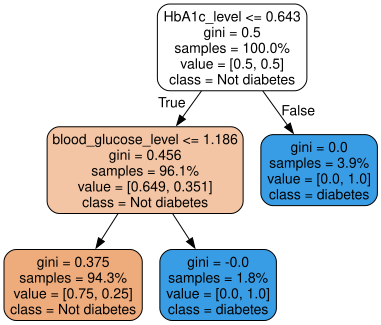

In [45]:
features_response = X_train.columns.tolist()

dot_data = export_graphviz(dt, out_file=None,filled=True,rounded=True,
                             feature_names=features_response, proportion=True, class_names=['Not diabetes', 'diabetes'])

graph = graphviz.Source(dot_data)
graph

### 1. Giải thích các thông số trong từng ô (Node)
Mỗi ô hình chữ nhật đại diện cho một nút (node) trong cây, chứa các thông tin thống kê sau:
*   **Tên điều kiện (dòng đầu tiên):** Ví dụ `HbA1c_level <= 0.643`. Đây là quy tắc để chia dữ liệu. Nếu điều kiện đúng (True), dữ liệu đi sang nhánh trái; nếu sai (False), dữ liệu đi sang nhánh phải.
*   **gini:** Chỉ số Gini Impurity (độ vẩn đục). Chỉ số này đo lường mức độ hỗn loạn của dữ liệu tại nút đó.
    *   `gini = 0.0`: Nút thuần khiết hoàn toàn (chỉ chứa 1 loại nhãn lớp duy nhất).
    *   `gini = 0.5`: Nút có độ hỗn loạn cao nhất (trong trường hợp phân loại nhị phân cân bằng 50/50).
*   **samples:** Tỷ lệ phần trăm tổng số mẫu dữ liệu đang được xét tại nút đó. Nút gốc luôn là 100%.
*   **value:** Mảng giá trị tỷ lệ của các lớp. Ví dụ `[0.649, 0.351]` nghĩa là tại nút này, xác suất là "Not diabetes" là 64.9% và "diabetes" là 35.1%.
*   **class:** Lớp dự đoán chiếm đa số tại nút đó (ví dụ: "Not diabetes" hoặc "diabetes").

### 2. Phân tích luồng quyết định (Đi từ trên xuống dưới)

**Bước 1: Nút Gốc (Root Node)**
*   **Điều kiện:** Kiểm tra chỉ số `HbA1c_level` (mức đường huyết trung bình) có nhỏ hơn hoặc bằng **0.643** hay không.
*   **Tình trạng:** Tại đây dữ liệu đang cân bằng (gini = 0.5, value = [0.5, 0.5]), tức là chưa phân biệt được bệnh hay không bệnh.
*   **Nhánh Phải (False):** Nếu `HbA1c_level > 0.643`:
    *   Đi đến nút màu xanh dương đậm bên phải.
    *   Tại đây `gini = 0.0` (thuần khiết hoàn toàn).
    *   **Kết luận ngay:** Người này được phân loại là **diabetes** (tiểu đường). Nhóm này chiếm 3.9% tổng số dữ liệu.

**Bước 2: Nhánh Trái (True)**
*   Nếu `HbA1c_level <= 0.643`, dữ liệu đi xuống nút màu cam nhạt bên trái.
*   **Điều kiện tiếp theo:** Kiểm tra `blood_glucose_level` (mức đường huyết tại thời điểm đo) có nhỏ hơn hoặc bằng **1.186** hay không.
*   Nhóm này chiếm 96.1% dữ liệu và phần lớn (64.9%) là không bị tiểu đường.

**Bước 3: Các nút lá (Leaf Nodes) từ bước 2**

*   **Nhánh Trái (True) - `blood_glucose_level <= 1.186`:**
    *   Đi xuống nút màu cam đậm dưới cùng bên trái.
    *   Nhóm này chiếm lượng lớn dữ liệu nhất (94.3%).
    *   Tỷ lệ "Not diabetes" chiếm ưu thế áp đảo (75%).
    *   **Kết luận:** Dự đoán là **Not diabetes** (Không bị tiểu đường).

*   **Nhánh Phải (False) - `blood_glucose_level > 1.186`:**
    *   Đi xuống nút màu xanh dương dưới cùng.
    *   Tại đây `gini = 0.0` (thuần khiết hoàn toàn).
    *   Nhóm này chiếm 1.8% dữ liệu.
    *   **Kết luận:** Dự đoán là **diabetes** (Bị tiểu đường).

### 3. Nhận xét tổng quan
1.  **Vai trò của HbA1c:** Đây là đặc trưng quan trọng nhất (nằm ở nút gốc). Chỉ cần `HbA1c_level > 0.643` là mô hình kết luận ngay là bị tiểu đường với độ tin cậy tuyệt đối (gini=0).
2.  **Vai trò của blood_glucose_level:** Với những người có HbA1c thấp, mô hình tiếp tục xét đến mức đường huyết. Nếu mức này cao (`> 1.186`), người đó vẫn bị xếp vào nhóm tiểu đường.
3.  **Hiệu suất:** Cây quyết định này có vẻ hoạt động rất hiệu quả trong việc tách lớp "diabetes" (các ô màu xanh dương đều có `gini = 0.0`, tức là dự đoán chính xác tuyệt đối trên tập dữ liệu huấn luyện này).
4.  **Màu sắc:**
    *   **Màu cam:** Đại diện cho lớp "Not diabetes". Màu càng đậm nghĩa là độ tin cậy càng cao (tỷ lệ người không bệnh càng lớn).
    *   **Màu xanh dương:** Đại diện cho lớp "diabetes".

**Tóm lại:** Quy tắc của mô hình này rất đơn giản:
*   Nếu HbA1c cao -> **Tiểu đường**.
*   Nếu HbA1c thấp nhưng Glucose máu cao -> **Tiểu đường**.
*   Nếu cả hai đều thấp -> **Không tiểu đường**.

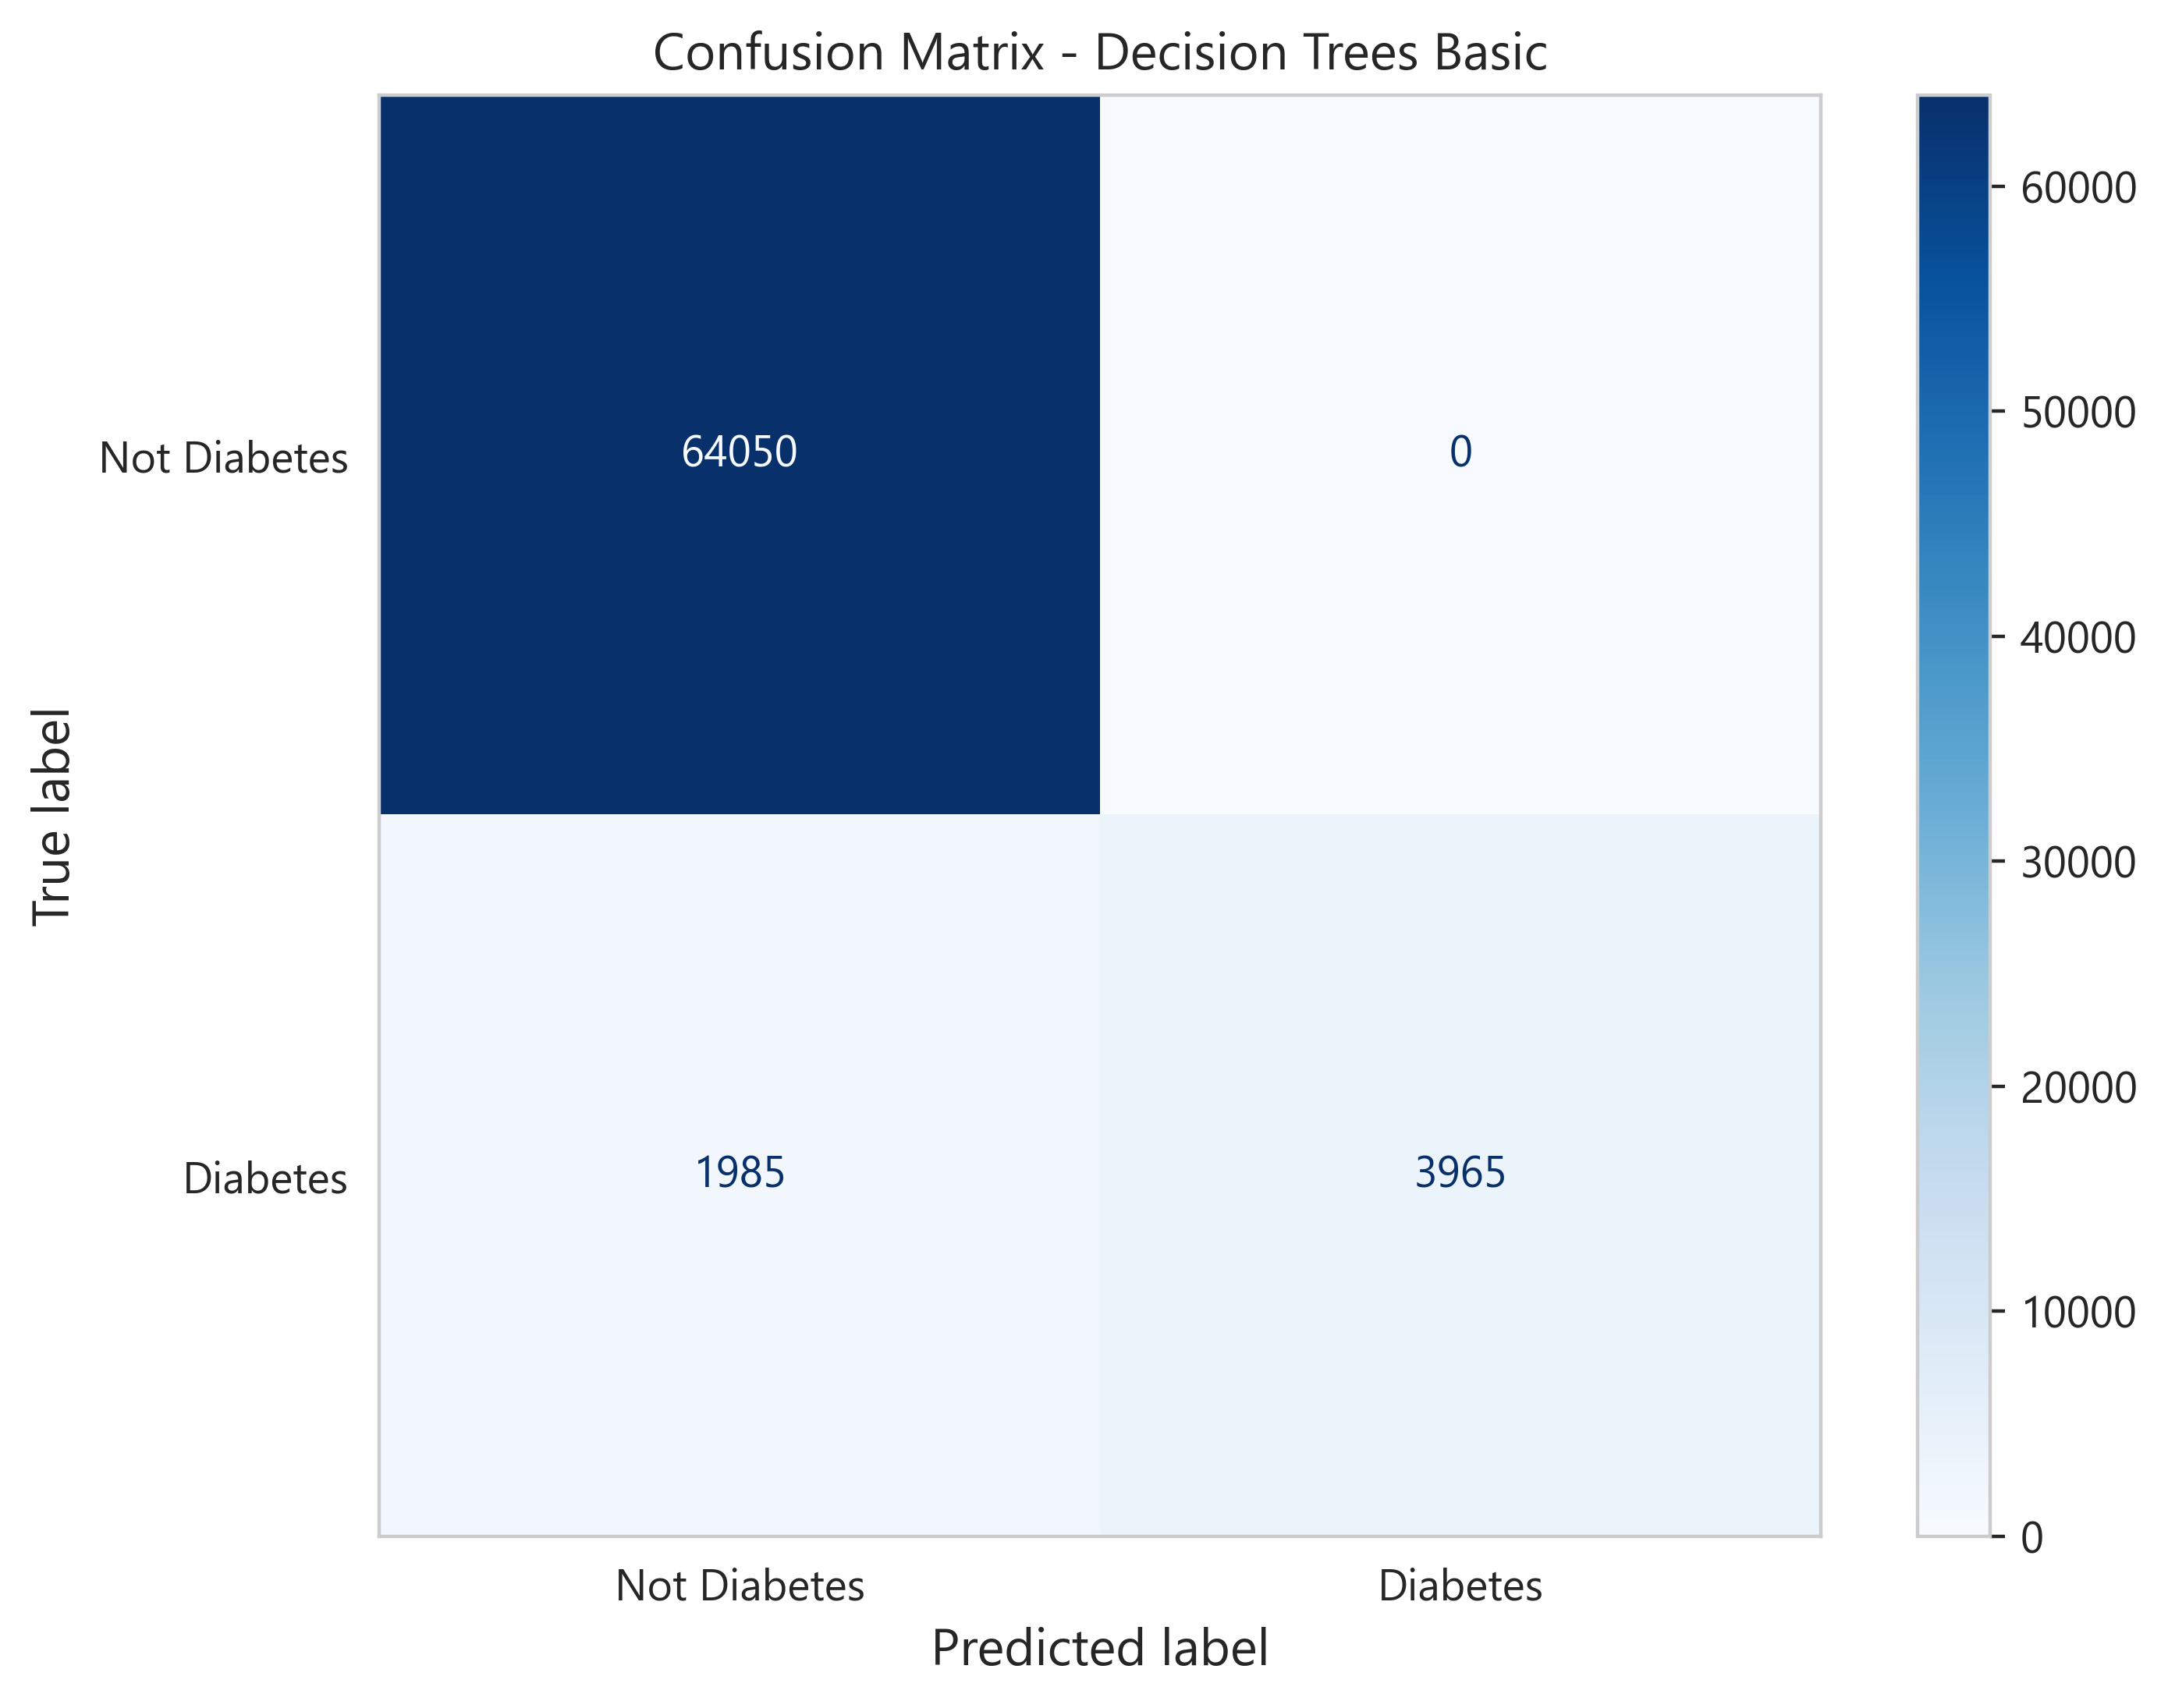

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Tính toán confusion matrix
cm = confusion_matrix(y_train, y_pred_base)

# 2. Vẽ biểu đồ
# Tạo figure và axes trước để kiểm soát kích thước
fig, ax = plt.subplots(figsize=(8, 6))

# SỬA LẠI THỨ TỰ LABEL: ['Not Diabetes', 'Diabetes'] tương ứng với [0, 1]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Diabetes', 'Diabetes'])

# Vẽ lên axes đã tạo (ax=ax)
disp.plot(cmap='Blues', ax=ax, values_format='d') # values_format='d' để hiển thị số nguyên, không phải số khoa học

plt.title("Confusion Matrix - Decision Trees Basic")
plt.grid(False) # Tắt lưới cho sạch mắt
plt.show()
plt.close()

### 1. Cấu trúc của biểu đồ
*   **Trục tung (True label):** Nhãn thực tế của dữ liệu (Sự thật).
    *   Hàng trên: "Not Diabetes" (Thực tế là Không bị tiểu đường).
    *   Hàng dưới: "Diabetes" (Thực tế là Bị tiểu đường).
*   **Trục hoành (Predicted label):** Nhãn do mô hình dự đoán.
    *   Cột trái: "Not Diabetes" (Mô hình đoán là Không bị tiểu đường).
    *   Cột phải: "Diabetes" (Mô hình đoán là Bị tiểu đường).
*   **Thanh màu (Color Bar):** Bên phải biểu đồ thể hiện mật độ số lượng. Màu càng đậm (xanh dương đậm) tương ứng với số lượng mẫu càng lớn.

### 2. Giải thích các chỉ số cụ thể (4 ô trong ma trận)

*   **Ô trên cùng bên trái (True Negative - TN): 64050**
    *   *Ý nghĩa:* Thực tế **Không bị bệnh** và mô hình dự đoán đúng là **Không bị bệnh**.
    *   *Nhận xét:* Con số này rất lớn (màu xanh đậm nhất), cho thấy mô hình cực kỳ xuất sắc trong việc nhận diện người khỏe mạnh.

*   **Ô trên cùng bên phải (False Positive - FP): 0**
    *   *Ý nghĩa:* Thực tế **Không bị bệnh** nhưng mô hình dự đoán sai là **Bị bệnh** (Báo động giả).
    *   *Nhận xét:* Đây là một kết quả lý tưởng tuyệt đối. Không có một trường hợp người khỏe mạnh nào bị mô hình "vu oan" là có bệnh. Độ đặc hiệu (Specificity) đạt 100%.

*   **Ô dưới cùng bên trái (False Negative - FN): 1985**
    *   *Ý nghĩa:* Thực tế **Bị bệnh** nhưng mô hình dự đoán sai là **Không bị bệnh** (Bỏ sót bệnh).
    *   *Nhận xét:* Đây là con số đáng lo ngại nhất trong y tế. Việc bỏ sót gần 2000 ca bệnh có thể dẫn đến việc bệnh nhân không được điều trị kịp thời. Đây là điểm yếu của mô hình này.

*   **Ô dưới cùng bên phải (True Positive - TP): 3965**
    *   *Ý nghĩa:* Thực tế **Bị bệnh** và mô hình dự đoán đúng là **Bị bệnh**.
    *   *Nhận xét:* Mô hình đã phát hiện chính xác gần 4000 ca bệnh.

### 3. Phân tích hiệu năng mô hình

Dựa trên các con số trên, ta có thể tính toán sơ bộ:

*   **Độ chính xác tổng thể (Accuracy):**
    $$ \frac{64050 + 3965}{64050 + 0 + 1985 + 3965} \approx 97.1\% $$
    => Mô hình có độ chính xác tổng thể rất cao. Tuy nhiên, do dữ liệu bị mất cân bằng (nhóm không bệnh chiếm đa số), con số này có thể gây hiểu nhầm.

*   **Độ nhạy (Recall) cho lớp Bệnh (Diabetes):**
    $$ \frac{3965}{1985 + 3965} \approx 66.6\% $$
    => Mô hình chỉ phát hiện được khoảng 2/3 số người thực sự bị bệnh. 1/3 số người bệnh đã bị bỏ sót.

*   **Độ chính xác dự báo (Precision) cho lớp Bệnh (Diabetes):**
    $$ \frac{3965}{0 + 3965} = 100\% $$
    => Nếu mô hình đã phán ai đó bị bệnh, thì chắc chắn người đó bị bệnh (không có báo động giả).

### 4. Kết luận và Đánh giá chung

*   **Ưu điểm:**
    *   Mô hình cực kỳ "an toàn" trong việc không đưa ra báo động giả (Precision tuyệt đối).
    *   Nhận diện người không bệnh cực tốt.

*   **Nhược điểm:**
    *   Mô hình đang bị **Underfitting (chưa khớp tốt)** với nhóm người bị bệnh (Recall thấp ~66.6%).
    *   Số lượng **False Negative (1985)** còn quá cao. Trong y tế, việc bỏ sót bệnh (False Negative) thường nguy hiểm hơn báo nhầm (False Positive).

*   **Đề xuất:** Cần cải thiện mô hình để giảm chỉ số ở ô góc dưới bên trái (1985) xuống, chấp nhận việc ô trên cùng bên phải (0) có thể tăng lên một chút để cân bằng lại độ nhạy (Recall). Có thể cần điều chỉnh lại trọng số dữ liệu (do mẫu Not Diabetes quá áp đảo so với Diabetes) hoặc thay đổi tham số của cây quyết định.

## **Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV và vẽ biểu đồ đánh giá mô hình với các tham số khác nhau**

Thực hiện 1, 2 và 3 như ở nhiệm vụ 1 để tải thư viện, nạp dữ liệu và chuẩn bị dữ liệu

Tạo cây quyết định và xác định các giá trị tham số có thể chọn để tìm tham số tối ưu

In [47]:
params = {'max_depth':[1, 2, 4, 6, 8, 10, 12],
            'min_samples_leaf': [20, 50, 100],  # Rất quan trọng để tránh lá cây quá nhỏ (overfit)
            'criterion': ['gini', 'entropy']
          }
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

cv = GridSearchCV(dt, param_grid=params, scoring = 'roc_auc',
                  n_jobs = None, refit = True, cv = 4, verbose=1,
                  error_score=np.nan,
                  return_train_score=True) 
cv.fit(X_train, y_train)

Fitting 4 folds for each of 42 candidates, totalling 168 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [1, 2, ...], 'min_samples_leaf': [20, 50, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


Vẽ biểu đồ đánh giá mô hình với các tham số chiều sâu của cây khác nhau

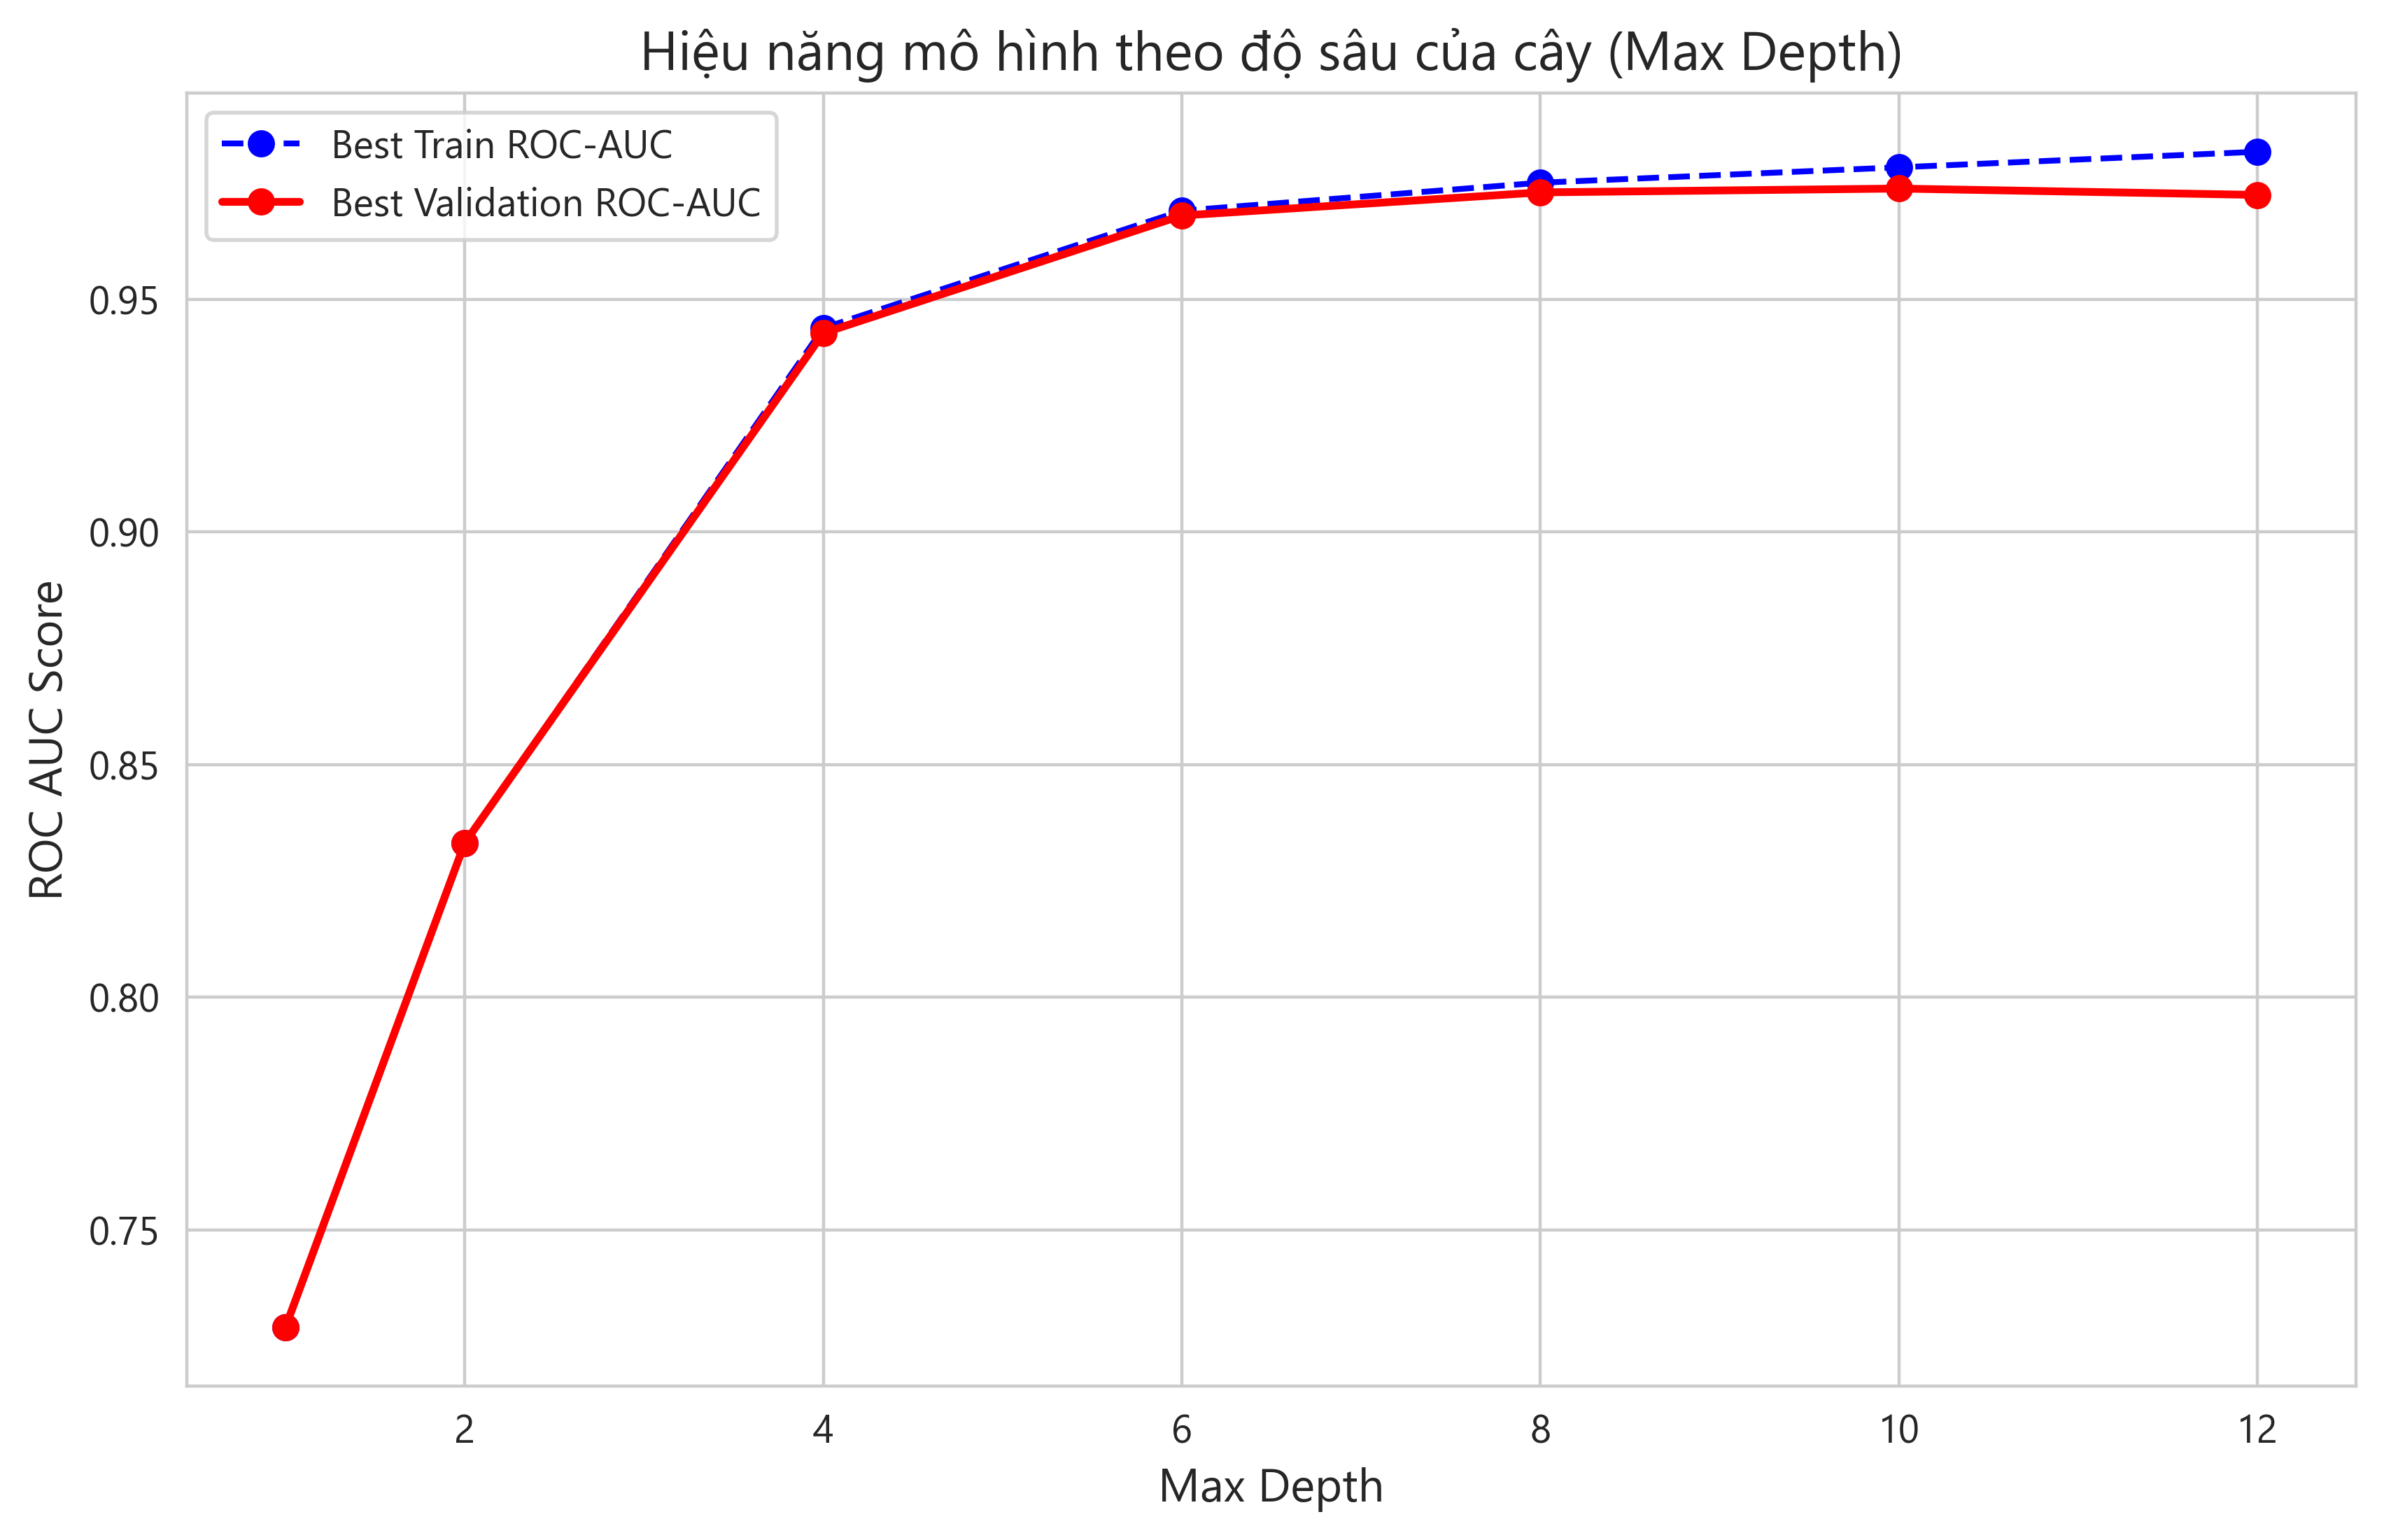

Bộ tham số tốt nhất: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 100}
ROC-AUC tốt nhất: 0.9738320709669912


In [48]:
cv_resuls_df = pd.DataFrame(cv.cv_results_)

# Nhóm theo 'param_max_depth' và lấy giá trị điểm số cao nhất (max) tại mỗi độ sâu
# Lý do: Tại mỗi độ sâu có nhiều cấu hình (do khác min_samples_leaf, criterion), ta chỉ quan tâm cái tốt nhất
grouped_results = cv_resuls_df.groupby('param_max_depth')[['mean_train_score', 'mean_test_score']].max()

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ đường Train
plt.plot(grouped_results.index, grouped_results['mean_train_score'], 
         marker='o', label='Best Train ROC-AUC', linestyle='--', color='blue')

# Vẽ đường Test (Validation)
plt.plot(grouped_results.index, grouped_results['mean_test_score'], 
         marker='o', label='Best Validation ROC-AUC', linewidth=2, color='red')

plt.title('Hiệu năng mô hình theo độ sâu của cây (Max Depth)', fontsize=14)
plt.xlabel('Max Depth', fontsize=12)
plt.ylabel('ROC AUC Score', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# In ra tham số tốt nhất
print("Bộ tham số tốt nhất:", cv.best_params_)
print("ROC-AUC tốt nhất:", cv.best_score_)

### 1. Các thành phần của biểu đồ
*   **Trục hoành (X-axis - Max Depth):** Biểu thị độ sâu tối đa của cây quyết định, chạy từ 1 đến 12. Độ sâu càng lớn, cây càng phức tạp và càng có nhiều quy tắc rẽ nhánh.
*   **Trục tung (Y-axis - ROC AUC Score):** Chỉ số đánh giá chất lượng mô hình (Diện tích dưới đường cong ROC). Giá trị càng gần 1.0 thì mô hình càng tốt.
*   **Đường nét đứt màu xanh (Best Train ROC-AUC):** Hiệu năng của mô hình trên tập dữ liệu huấn luyện (Train set).
*   **Đường nét liền màu đỏ (Best Validation ROC-AUC):** Hiệu năng của mô hình trên tập dữ liệu kiểm thử/xác thực (Validation set). Đây là đường quan trọng hơn để đánh giá khả năng tổng quát hóa của mô hình thực tế.

### 2. Phân tích xu hướng
*   **Giai đoạn 1: Tăng trưởng nhanh (Depth từ 1 đến 4)**
    *   Cả hai đường xanh (Train) và đỏ (Validation) đều tăng rất dốc.
    *   Khi độ sâu tăng từ 1 lên 2, rồi lên 4, khả năng phân loại của mô hình cải thiện vượt bậc (từ dưới 0.75 lên gần 0.95).
    *   *Ý nghĩa:* Ở mức độ sâu thấp, mô hình đang học các quy tắc quan trọng nhất của dữ liệu.

*   **Giai đoạn 2: Bão hòa (Depth từ 4 đến 6)**
    *   Tốc độ tăng trưởng chậm lại rõ rệt.
    *   Đường màu đỏ và xanh vẫn bám rất sát nhau, cho thấy mô hình vẫn đang học tốt và chưa có dấu hiệu Overfitting.
    *   Tại `Max Depth = 6`, chỉ số ROC-AUC đạt mức rất cao (khoảng trên 0.96).

*   **Giai đoạn 3: Tách biệt và dấu hiệu Overfitting (Depth > 8)**
    *   Từ độ sâu 8 trở đi, đường màu xanh (Train) vẫn tiếp tục đi lên nhẹ, tiệm cận mức hoàn hảo. Điều này dễ hiểu vì cây càng sâu thì càng "nhớ" kỹ dữ liệu huấn luyện.
    *   Tuy nhiên, đường màu đỏ (Validation) bắt đầu đi ngang và có xu hướng giảm nhẹ hoặc thấp hơn đường xanh tại `Depth = 12`.
    *   *Ý nghĩa:* Khoảng cách giữa đường xanh và đỏ bắt đầu mở rộng (dù chưa quá lớn). Đây là dấu hiệu cho thấy nếu tăng độ sâu thêm nữa, mô hình sẽ bắt đầu học vẹt (Overfitting) – tức là tốt trên tập train nhưng không cải thiện thêm trên tập kiểm thử.

### 3. Nhận xét và Kết luận
*   **Điểm tối ưu (Sweet Spot):** Dựa trên biểu đồ, **Max Depth = 6** hoặc **Max Depth = 8** là điểm lý tưởng nhất.
    *   Tại mức 6, hiệu năng trên tập Validation đã đạt mức gần như cao nhất và đường đỏ vẫn bám sát đường xanh.
    *   Tại mức 8, hiệu năng Validation đạt đỉnh (peak), nhưng mức tăng so với mức 6 là không đáng kể, trong khi độ phức tạp tính toán lại tăng lên.
*   **Tại sao không chọn Depth = 12?** Mặc dù đường xanh (Train) cao nhất tại đây, nhưng đường đỏ (Validation) không tăng thêm (thậm chí hơi thấp hơn đường xanh). Việc chọn cây quá sâu (depth 12) sẽ làm mô hình cồng kềnh, tốn tài nguyên tính toán hơn mà không đem lại lợi ích thực tế cho việc dự đoán dữ liệu mới.

**Tóm lại:** Biểu đồ cho thấy mô hình Decision Tree này hoạt động rất tốt. Độ sâu cây nên được giới hạn ở mức khoảng **6 đến 8** để đạt được sự cân bằng tốt nhất giữa độ chính xác và khả năng tổng quát hóa, tránh việc mô hình quá phức tạp.

## **Nhiệm vụ 3: Xây dựng rừng cây (random forest)**

1. Thực hiện 1, 2 và 3 như ở nhiệm vụ 1 để tải thư viện, nạp dữ liệu và chuẩn bị dữ liệu 
2. Tạo rừng cây với lớp RandomForestClassifier trong Scikit-Learn 

In [49]:
# 1. KHỞI TẠO RANDOM FOREST
# Sửa 1: class_weight='balanced'
# Sửa 2: Tăng max_depth lên (3 là quá nông cho RF), hoặc để None. Để 3 mô hình sẽ bị underfitting (quá đơn giản).
rf = RandomForestClassifier(n_estimators=10, criterion='gini', max_depth=10,
                            min_samples_split=2, min_samples_leaf=1,
                            min_weight_fraction_leaf=0.0, max_features='sqrt',
                            max_leaf_nodes=None, min_impurity_decrease=0.0,
                            bootstrap=True, oob_score=False, n_jobs=None,
                            random_state=4, verbose=0, warm_start=False, class_weight='balanced')

3. Tìm tham số tối ưu cho mô hình rừng cây và thực hiện train với tham số tối ưu đó

In [50]:
rf_params_ex = {'n_estimators':list(range(10,110,10))}

cv_rf_ex = GridSearchCV(rf, param_grid=rf_params_ex, scoring='roc_auc',
                        n_jobs=None, refit=True, cv=4, verbose=1,
                        error_score=0.0,
                        return_train_score=True)
cv_rf_ex.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


,estimator,RandomForestC...andom_state=4)
,param_grid,"{'n_estimators': [10, 20, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,0.0
,return_train_score,True
,n_estimators,60


4. Vẽ biểu đồ đánh giá mô hình rừng cây với các tham số số cây có trong rừng khác nhau 

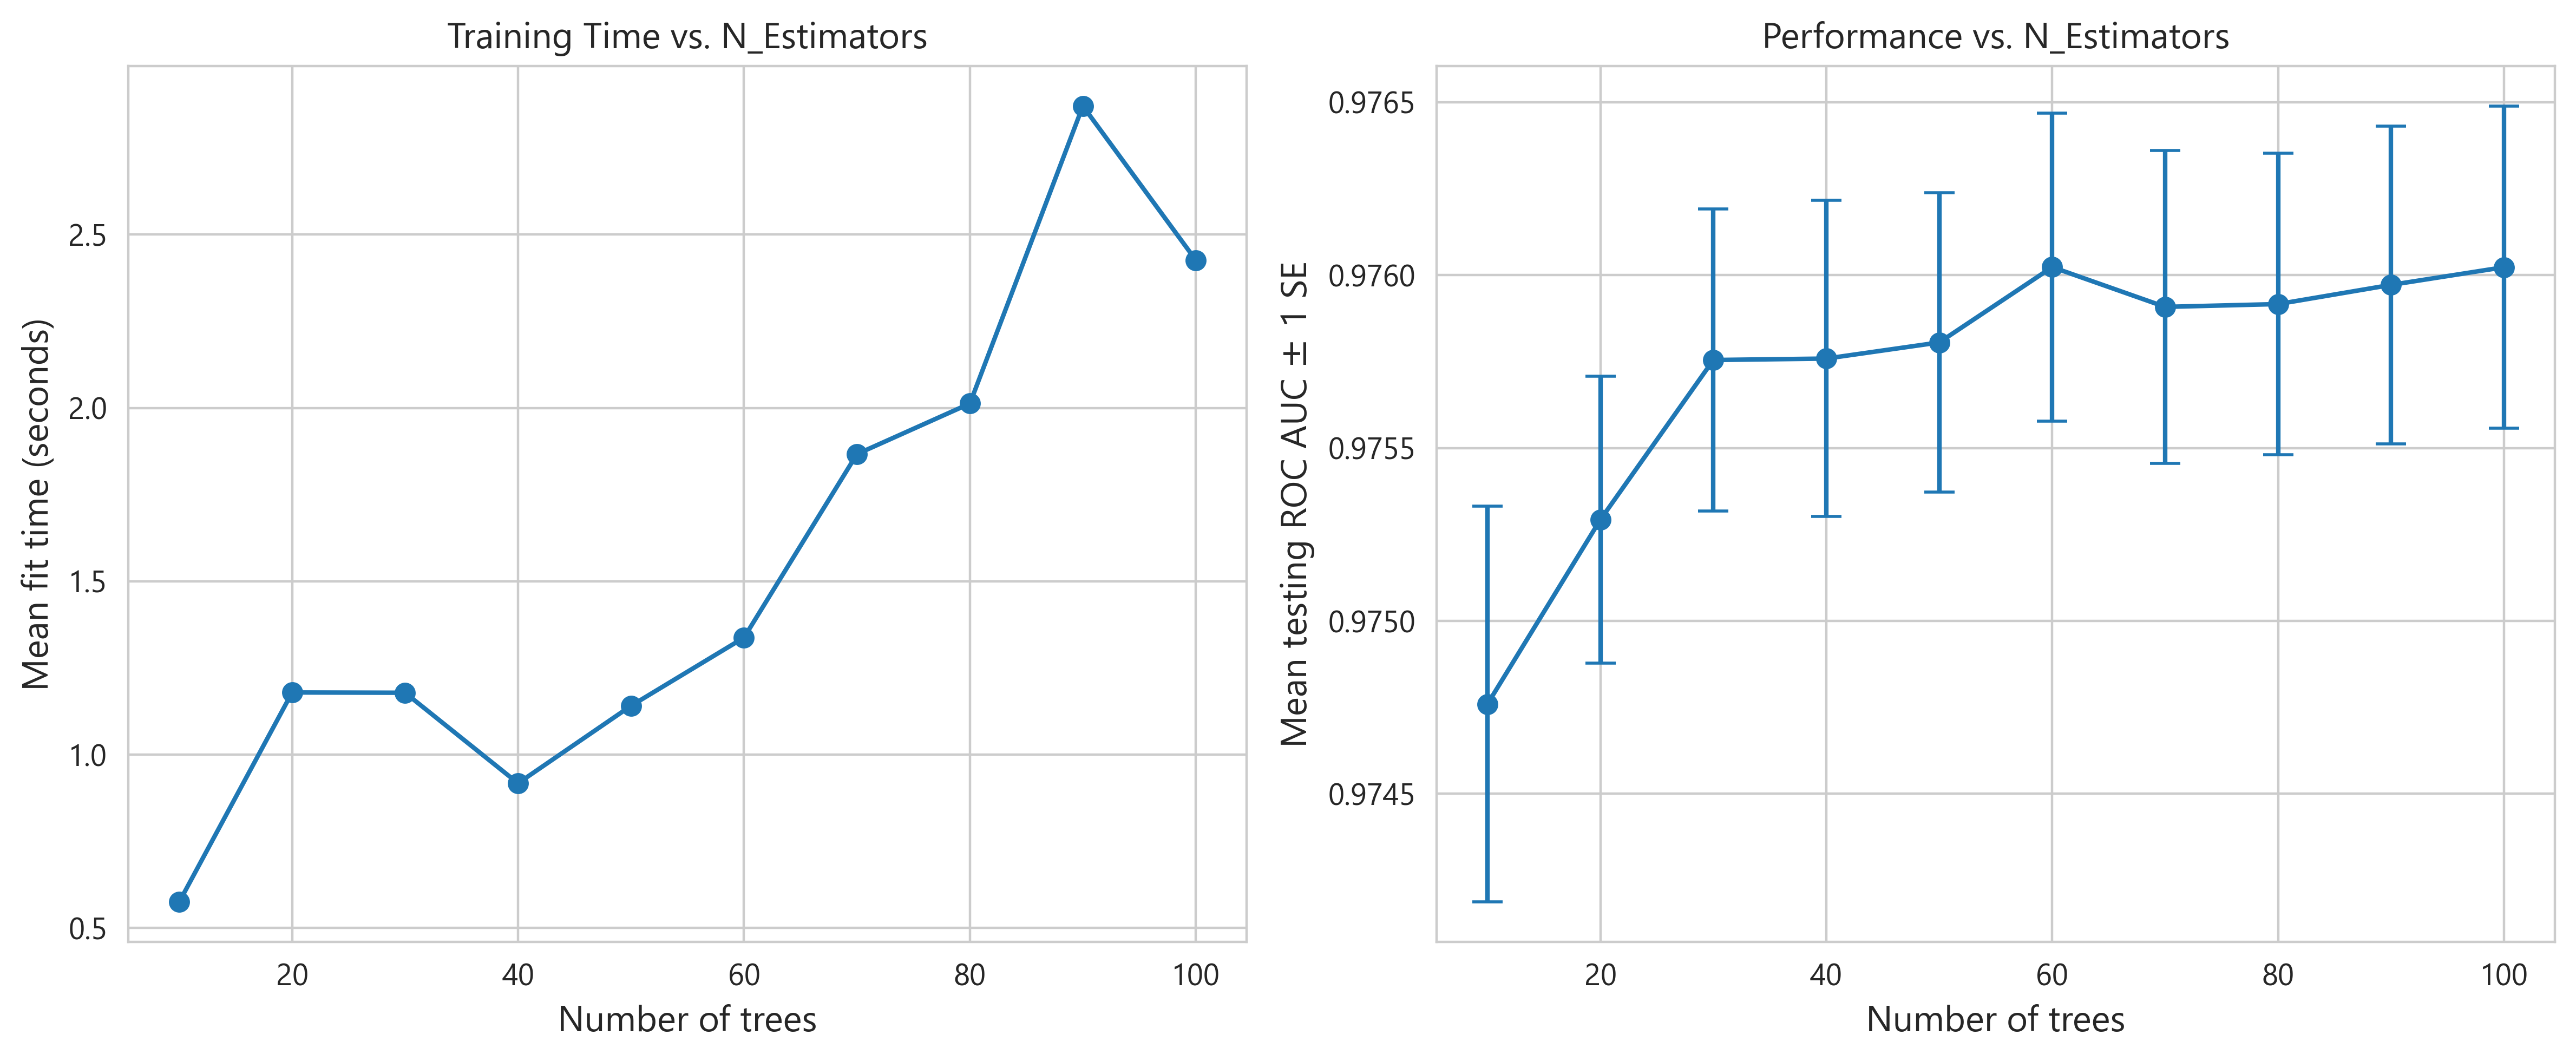

In [51]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_) 
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5)) 

axs[0].plot(cv_rf_ex_results_df['param_n_estimators'], 
cv_rf_ex_results_df['mean_fit_time'], '-o') 

axs[0].set_xlabel('Number of trees') 
axs[0].set_ylabel('Mean fit time (seconds)') 
axs[0].set_title('Training Time vs. N_Estimators')

axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'], 
cv_rf_ex_results_df['mean_test_score'], 
yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4), fmt='-o', capsize=5) 

axs[1].set_xlabel('Number of trees') 
axs[1].set_ylabel(r'Mean testing ROC AUC $\pm$ 1 SE ') 
axs[1].set_title('Performance vs. N_Estimators')
plt.tight_layout() 
plt.show()
plt.close()

### 1. Biểu đồ bên trái: Training Time vs. N_Estimators
Biểu đồ này thể hiện mối quan hệ giữa số lượng cây (`Number of trees`) và thời gian huấn luyện trung bình (`Mean fit time`).

*   **Xu hướng chung:** Có xu hướng tăng dần. Điều này là hiển nhiên vì càng nhiều cây, máy tính càng phải thực hiện nhiều phép tính hơn, dẫn đến thời gian xử lý lâu hơn.
    *   Tại 10 cây: Thời gian khoảng 0.6 giây.
    *   Tại 90 cây: Thời gian tăng lên gần 2.9 giây (gấp gần 5 lần).
*   **Điểm bất thường:** Đồ thị không phải là một đường thẳng mượt mà. Có những điểm bị sụt giảm kỳ lạ (ví dụ tại mốc 40 cây và 100 cây thời gian lại giảm xuống so với mốc trước đó).
    *   *Giải thích:* Thời gian huấn luyện thực tế phụ thuộc vào tài nguyên máy tính (CPU/RAM) tại thời điểm chạy. Các điểm sụt giảm này có thể do tại thời điểm đó máy tính rảnh rỗi hơn, hoặc do cơ chế caching của hệ thống, nên việc xử lý nhanh hơn dự kiến. Tuy nhiên, xu hướng chủ đạo vẫn là **nhiều cây = tốn nhiều thời gian**.

### 2. Biểu đồ bên phải: Performance vs. N_Estimators
Biểu đồ này thể hiện mối quan hệ giữa số lượng cây và hiệu năng mô hình (đo bằng chỉ số ROC AUC trên tập kiểm thử). Các thanh dọc (vạch chữ I) biểu thị độ lệch chuẩn (Standard Error), cho thấy mức độ biến động của kết quả qua các lần kiểm thử chéo (Cross-validation).

*   **Giai đoạn tăng trưởng (10 - 30 cây):** Hiệu năng tăng rất nhanh. Từ mức dưới 0.9748 lên khoảng 0.9758. Việc thêm cây ở giai đoạn này mang lại lợi ích rất lớn.
*   **Giai đoạn bão hòa (60 - 100 cây):** Từ mốc 60 cây trở đi, đường biểu diễn bắt đầu đi ngang (plateau).
    *   Tại 60 cây, chỉ số đạt khoảng 0.9760.
    *   Tại 100 cây, chỉ số vẫn loanh quanh 0.9760.
    *   **Quan trọng:** Các thanh sai số (Error bars) giao nhau rất nhiều ở giai đoạn này. Điều này có nghĩa là sự khác biệt về hiệu năng giữa 60, 70, 80 hay 100 cây là **không có ý nghĩa thống kê**. Việc thêm cây không làm mô hình thông minh hơn đáng kể.

### 3. Kết luận và Kiến nghị (Trade-off)

Khi kết hợp cả hai biểu đồ, ta đang giải bài toán đánh đổi giữa **Chi phí (Thời gian)** và **Lợi ích (Hiệu năng)**:

*   **Nếu chọn 100 cây:** Hiệu năng đạt cao nhất (nhỉnh hơn một chút xíu), nhưng phải trả giá bằng thời gian huấn luyện lâu nhất (khoảng 2.5 giây).
*   **Nếu chọn 60 cây:** Hiệu năng gần như tương đương với 100 cây (chênh lệch không đáng kể), nhưng thời gian huấn luyện chỉ mất khoảng 1.2 - 1.3 giây (nhanh gấp đôi so với 90-100 cây).

**=> Lựa chọn tối ưu (Sweet Spot):** Nên chọn `N_Estimators` trong khoảng **60**.
Tại điểm này, mô hình đã hội tụ đủ tốt (đạt đỉnh hiệu năng) nhưng chưa tiêu tốn quá nhiều tài nguyên tính toán không cần thiết. Việc tăng thêm số cây sau mốc này chỉ làm tốn thời gian mà không cải thiện kết quả dự đoán.

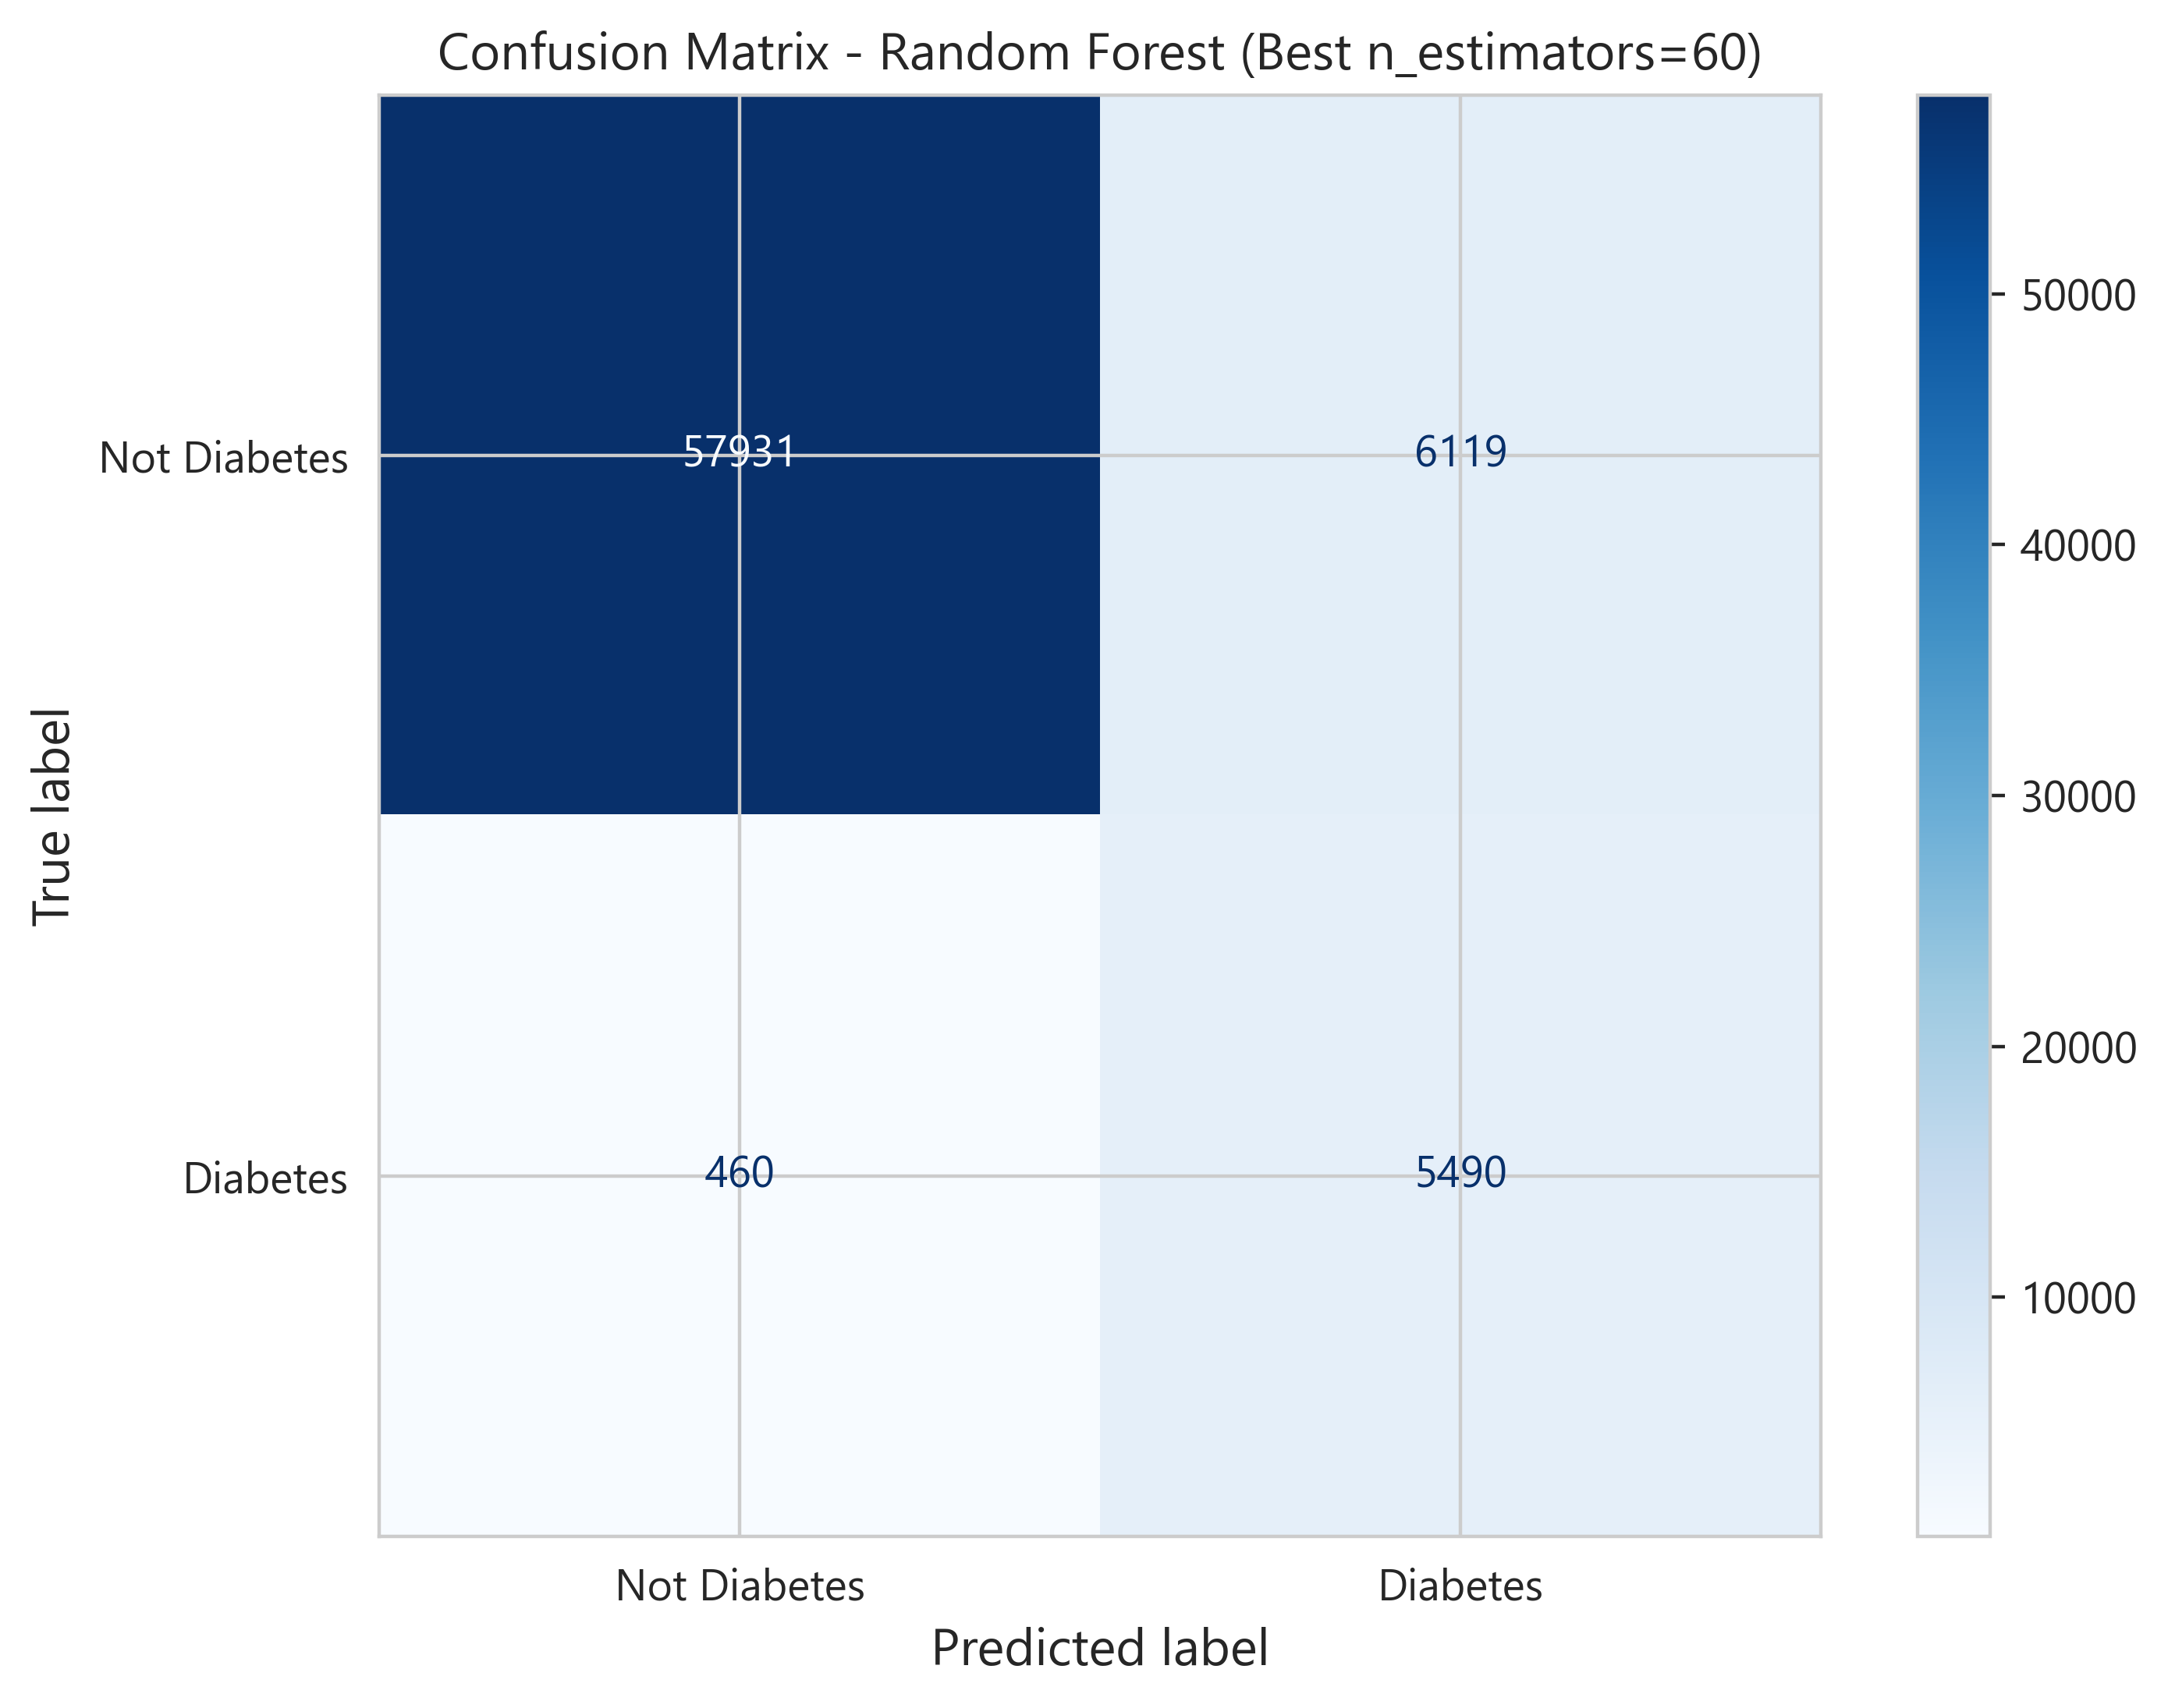

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Sửa 3: Dự đoán lại bằng mô hình Random Forest tốt nhất vừa tìm được
y_pred_rf = cv_rf_ex.best_estimator_.predict(X_train)

# Tính toán confusion matrix
cm = confusion_matrix(y_train, y_pred_rf)

# Vẽ
fig, ax = plt.subplots(figsize=(8, 6))

# Sửa 4: Nhãn đúng cho bài toán Tiểu đường
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Diabetes', 'Diabetes'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f"Confusion Matrix - Random Forest (Best n_estimators={cv_rf_ex.best_params_['n_estimators']})")
plt.show()
plt.close()

### 1. Giải thích các chỉ số cụ thể (4 ô trong ma trận)

*   **Ô trên cùng bên trái (True Negative - TN): 57931**
    *   *Ý nghĩa:* Thực tế **Không bị bệnh** và mô hình dự đoán đúng là **Không bị bệnh**.
    *   *So sánh:* Số lượng này giảm so với mô hình Decision Tree đơn lẻ ở hình 2 (từ 64050 xuống 57931).

*   **Ô trên cùng bên phải (False Positive - FP): 6119**
    *   *Ý nghĩa:* Thực tế **Không bị bệnh** nhưng mô hình dự đoán sai là **Bị bệnh** (Báo động giả).
    *   *Nhận xét:* Đây là sự thay đổi lớn nhất. Trong khi mô hình cây đơn lẻ (hình 2) có FP = 0 (không báo nhầm ai), thì mô hình Random Forest này lại báo nhầm hơn 6000 người khỏe mạnh là có bệnh. Điều này làm giảm độ chính xác (Precision) của mô hình.

*   **Ô dưới cùng bên trái (False Negative - FN): 460**
    *   *Ý nghĩa:* Thực tế **Bị bệnh** nhưng mô hình dự đoán sai là **Không bị bệnh** (Bỏ sót bệnh).
    *   *Nhận xét:* Đây là sự cải thiện **cực kỳ quan trọng**. Mô hình cây đơn lẻ bỏ sót tới 1985 ca bệnh, trong khi Random Forest chỉ bỏ sót 460 ca. Số lượng ca bệnh bị bỏ sót đã giảm đi hơn 4 lần.

*   **Ô dưới cùng bên phải (True Positive - TP): 5490**
    *   *Ý nghĩa:* Thực tế **Bị bệnh** và mô hình dự đoán đúng là **Bị bệnh**.
    *   *Nhận xét:* Số lượng phát hiện đúng bệnh tăng mạnh từ 3965 (cây đơn lẻ) lên 5490.

### 2. Đánh giá hiệu năng mô hình (So sánh với Decision Tree đơn lẻ)

Chúng ta hãy tính toán các chỉ số quan trọng để thấy sự đánh đổi:

*   **Độ nhạy (Recall) - Khả năng phát hiện bệnh:**
    *   Công thức: $TP / (TP + FN)$
    *   Giá trị: $5490 / (5490 + 460) \approx \mathbf{92.3\%}$
    *   *So sánh:* Tăng vọt so với mức **66.6%** của cây đơn lẻ.
    *   *Kết luận:* Random Forest cực kỳ nhạy bén trong việc tìm ra người bệnh. Nó bắt được hơn 90% số ca bệnh thực tế.

*   **Độ chính xác dự báo (Precision) - Độ tin cậy của dự báo bệnh:**
    *   Công thức: $TP / (TP + FP)$
    *   Giá trị: $5490 / (5490 + 6119) \approx \mathbf{47.3\%}$
    *   *So sánh:* Giảm thê thảm so với mức **100%** của cây đơn lẻ.
    *   *Kết luận:* Cứ 2 người mà mô hình này phán là "Bị bệnh", thì chỉ có khoảng 1 người thực sự bị bệnh, người còn lại là báo động giả.

### 3. Tổng kết và Nhận xét chung

Mô hình Random Forest này thể hiện một sự **đánh đổi (Trade-off)** kinh điển trong học máy:

1.  **Chấp nhận "Báo nhầm" để không "Bỏ sót":**
    *   Mô hình đã trở nên "thận trọng" hơn rất nhiều. Nó thà báo nhầm một người khỏe là có bệnh (để đi kiểm tra lại) còn hơn là để sót một người bệnh đi về nhà mà không được chữa trị.
    *   Trong y tế sàng lọc (screening), chiến lược này thường được ưu tiên hơn. Việc **False Negative (bỏ sót bệnh)** nguy hiểm hơn nhiều so với **False Positive (báo nhầm)**. Một người bị báo nhầm chỉ mất công đi xét nghiệm lại, nhưng một người bị bỏ sót có thể nguy hiểm đến tính mạng.

2.  **Hiệu quả hơn về mặt Y khoa:**
    *   Mặc dù độ chính xác tổng thể có thể thấp hơn một chút do lượng báo nhầm tăng lên, nhưng giá trị thực tế của mô hình này cao hơn nhiều so với mô hình cây đơn lẻ ở hình 2, vì nó bảo vệ được sinh mạng bệnh nhân tốt hơn (Recall 92.3%).

**Kết luận:** Đây là một mô hình Random Forest tốt cho mục đích sàng lọc bệnh tiểu đường, nơi ưu tiên cao nhất là không được bỏ sót bệnh nhân (tối ưu hóa Recall), chấp nhận tỷ lệ báo động giả cao hơn.

5. Xem tham số tốt nhất của rừng cây, xem mức độ quan trọng của từng feature trong mô hình với tham 
số tốt nhất

Best params: {'n_estimators': 60}


<Figure size 4000x2400 with 0 Axes>

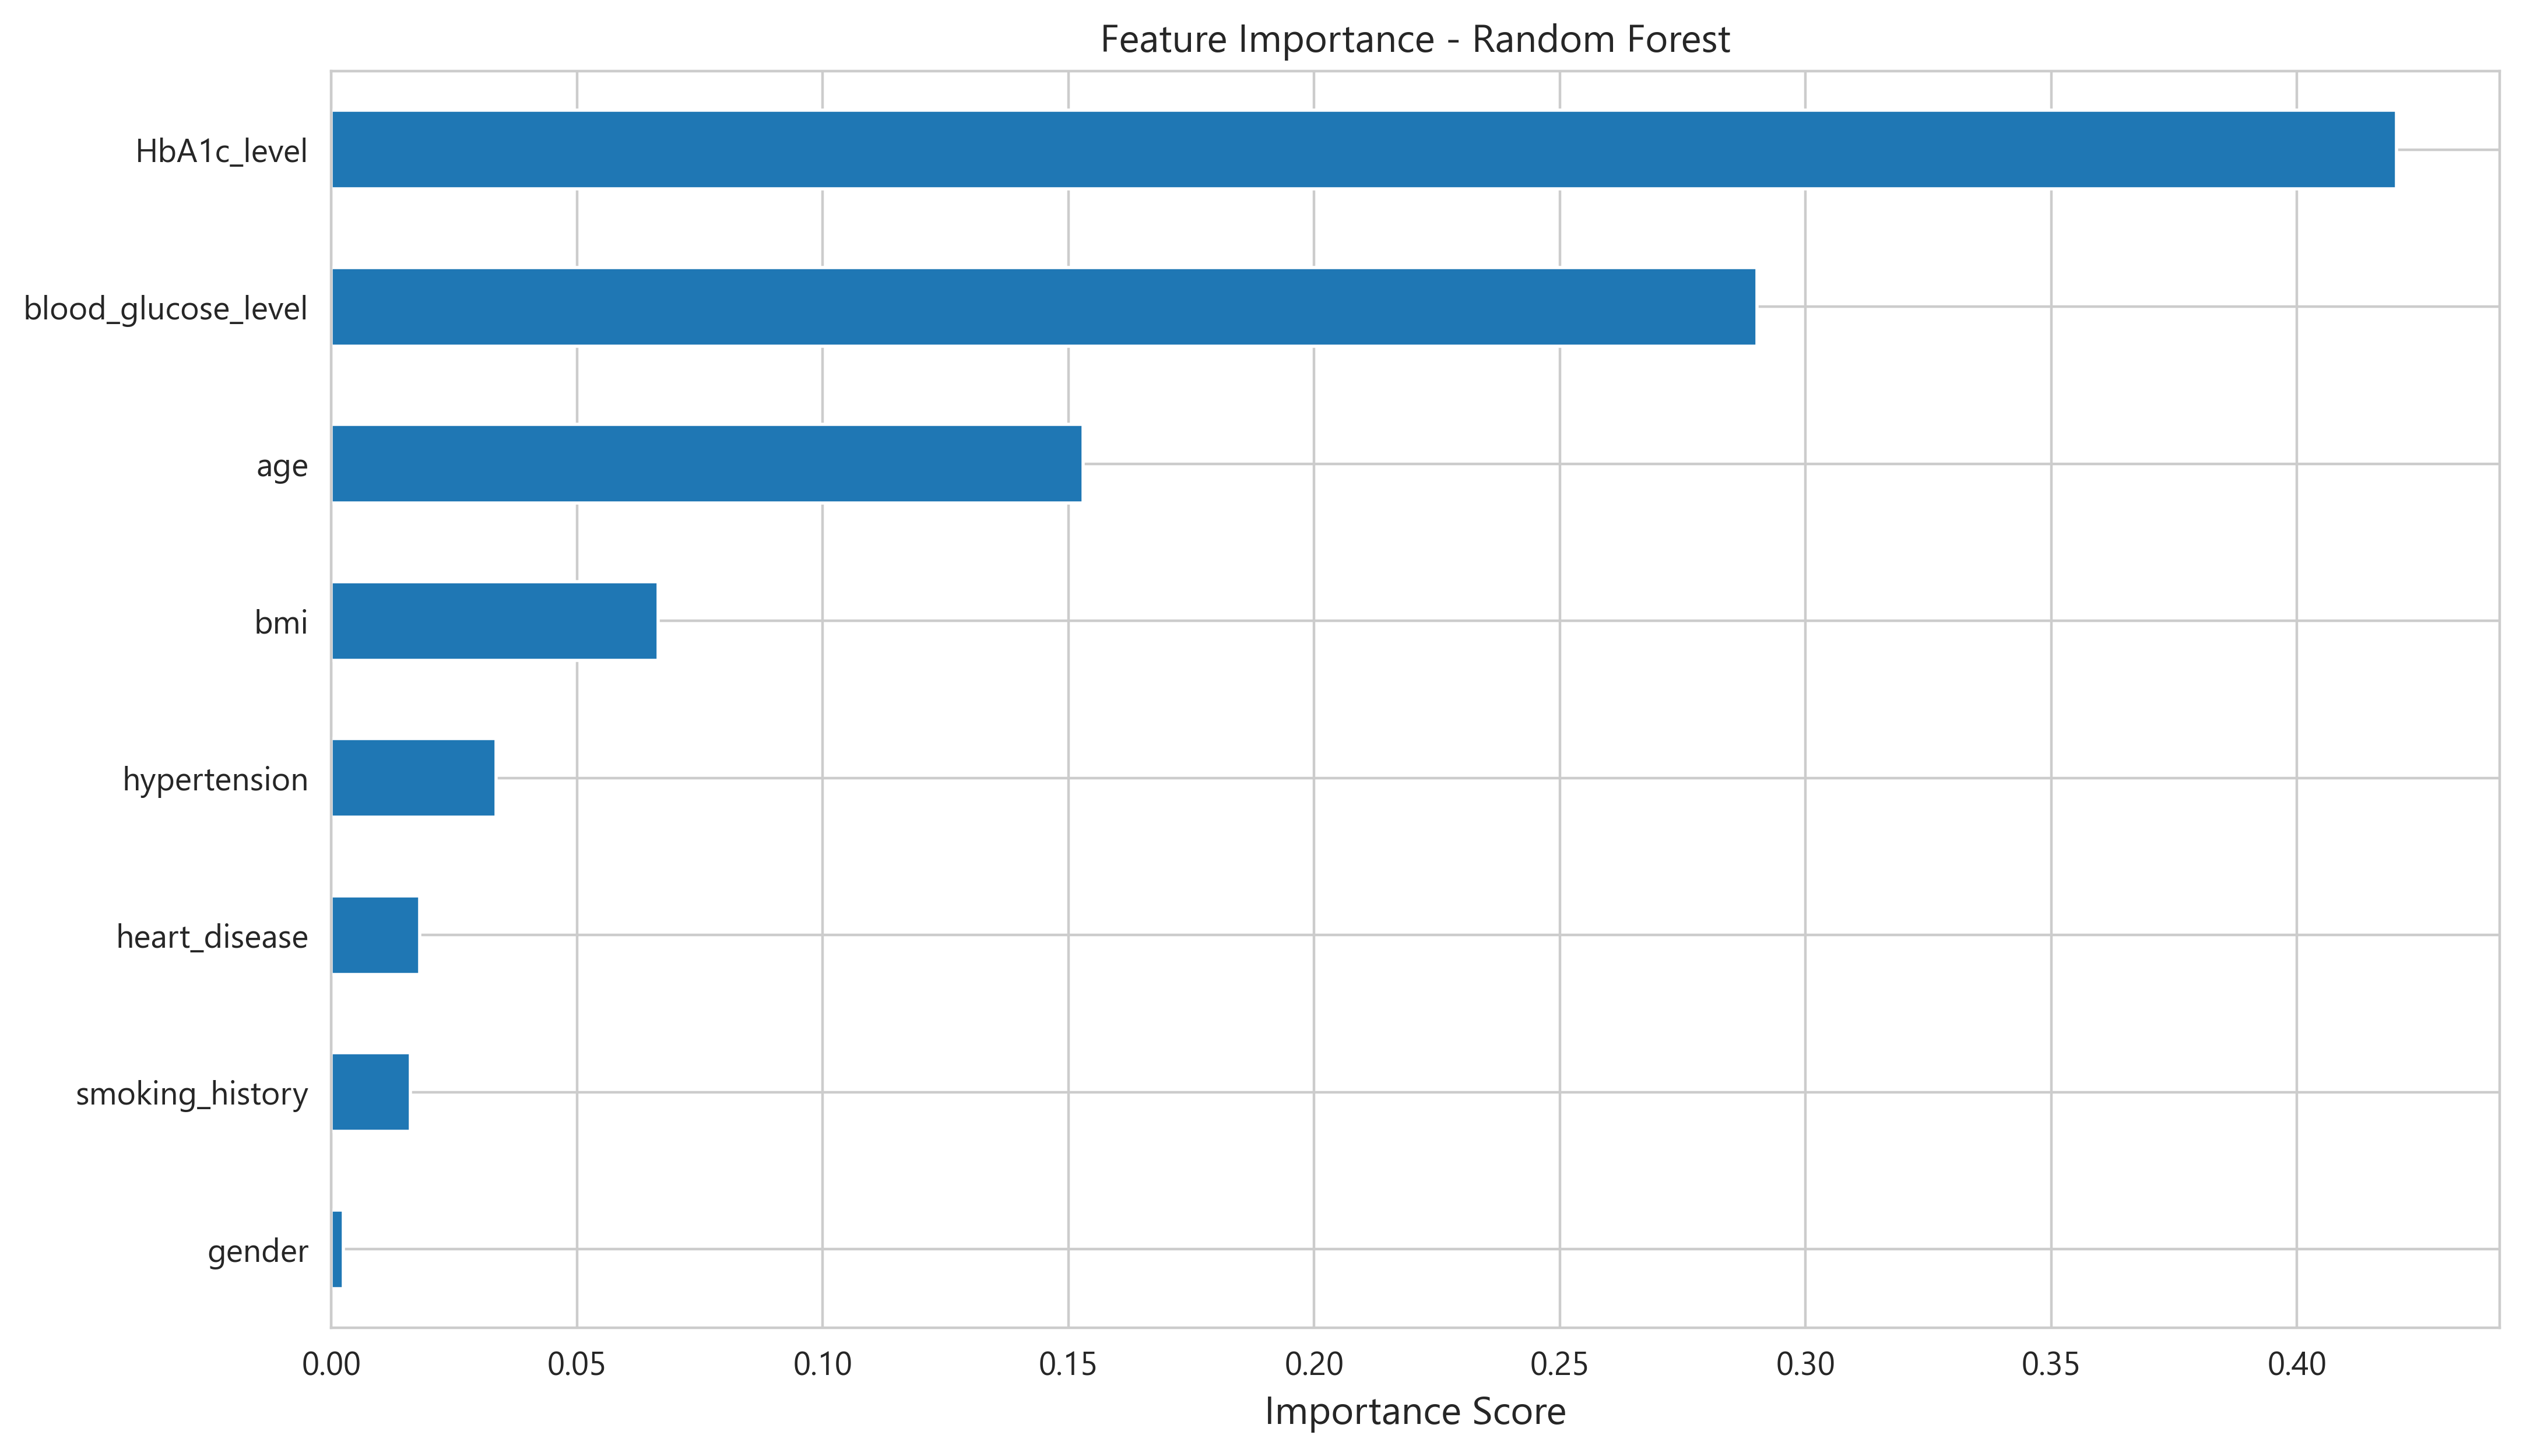

In [53]:
print("Best params:", cv_rf_ex.best_params_) 
# {'n_estimators': 50} 
cv_rf_ex.best_params_ 
# the feature names and importances 
feat_imp_df = pd.DataFrame({ 
'Importance':cv_rf_ex.best_estimator_.feature_importances_}, 
index=features_response) 

plt.figure(figsize=(10, 6))

feat_imp_df.sort_values('Importance', ascending=True).plot.barh(legend=False)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()
plt.close()

### 1. Nhóm yếu tố "Quyết định" (Ảnh hưởng cực lớn)
*   **HbA1c_level (Mức đường huyết trung bình):**
    *   *Vị trí:* Đứng đầu bảng với điểm số vượt trội (khoảng 0.42 - 0.43).
    *   *Ý nghĩa:* Đây là chỉ số vàng trong chẩn đoán tiểu đường. Việc nó đứng đầu là hoàn toàn hợp lý về mặt y học. Nó đóng góp hơn 40% vào quyết định của mô hình.
*   **blood_glucose_level (Mức đường huyết tại thời điểm đo):**
    *   *Vị trí:* Đứng thứ hai, điểm số khoảng 0.29.
    *   *Ý nghĩa:* Kết hợp với HbA1c, hai chỉ số về đường huyết này chiếm tổng cộng khoảng **70%** sức mạnh dự đoán của toàn bộ mô hình. Điều này khẳng định rằng: muốn biết có bị tiểu đường hay không, xét nghiệm máu là quan trọng nhất.

### 2. Nhóm yếu tố "Ảnh hưởng trung bình"
*   **age (Tuổi tác):**
    *   *Vị trí:* Đứng thứ 3, điểm số khoảng 0.15.
    *   *Ý nghĩa:* Tuổi tác là yếu tố nguy cơ không thể chối cãi. Người lớn tuổi có nguy cơ mắc tiểu đường cao hơn. Tuy nhiên, so với chỉ số xét nghiệm máu trực tiếp thì tuổi tác chỉ là yếu tố bổ trợ.
*   **bmi (Chỉ số khối cơ thể):**
    *   *Vị trí:* Đứng thứ 4, điểm số khoảng 0.06 - 0.07.
    *   *Ý nghĩa:* Thể hiện mối liên hệ giữa béo phì và tiểu đường. Tuy nhiên, mức độ ảnh hưởng của nó thấp hơn nhiều so với tuổi và đường huyết.

### 3. Nhóm yếu tố "Ảnh hưởng thấp" (Ít quan trọng)
Các yếu tố còn lại có điểm số rất thấp (dưới 0.05), bao gồm:
*   **hypertension (Cao huyết áp)**
*   **heart_disease (Bệnh tim mạch)**
*   **smoking_history (Lịch sử hút thuốc)**
*   **gender (Giới tính)**: Gần như bằng 0.

*   *Giải thích:* Mặc dù về mặt y học, cao huyết áp, bệnh tim hay hút thuốc đều là các yếu tố nguy cơ *liên quan* đến tiểu đường, nhưng trong ngữ cảnh của bộ dữ liệu này, khi đã biết được chỉ số đường huyết (HbA1c và Glucose) thì các thông tin về bệnh nền này không mang lại thêm nhiều giá trị dự đoán mới (redundant information). Ví dụ: Một người có HbA1c cao thì khả năng bị tiểu đường là rất cao, bất kể họ có hút thuốc hay bị cao huyết áp hay không.

### 4. Kết luận và Ứng dụng thực tế

1.  **Sự thống trị của chỉ số sinh học:** Mô hình khẳng định rằng các xét nghiệm lâm sàng (HbA1c, Glucose) là không thể thay thế. Các yếu tố nhân khẩu học (tuổi, giới tính) hay lối sống chỉ đóng vai trò phụ.
2.  **Tối ưu hóa thu thập dữ liệu:** Nếu muốn xây dựng một bộ kit xét nghiệm nhanh (sàng lọc), ta có thể chỉ cần thu thập 2 chỉ số là `HbA1c` và `blood_glucose`, có thể thêm `age`. Ta có thể bỏ qua `gender` hoặc `smoking_history` để tiết kiệm thời gian thu thập tin mà không làm giảm đáng kể độ chính xác của mô hình.
3.  **Độ tin cậy:** Kết quả của mô hình Random Forest này rất phù hợp với kiến thức y khoa hiện đại, làm tăng độ tin cậy (trustworthiness) của mô hình AI này khi áp dụng vào thực tế.